# O truque do kernel

**Tema:** Aprendizado Supervisionado › Máquinas de Vetores de Suporte

Este notebook começa mostrando POR QUE um kernel funciona — calculando um
mapeamento polinomial explícito e comparando com o kernel, produto por
produto — e termina comparando kernel linear, polinomial e RBF num
problema que nenhum classificador linear resolve.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_circles, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, GridSearchCV

rng = np.random.default_rng(24)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
np.set_printoptions(precision=4, suppress=True)
print("pronto")

pronto


## 1. Provando o truque: kernel polinomial = produto interno no espaço expandido

Para duas dimensões, $\phi(x) = (x_1^2, \sqrt{2}x_1x_2, x_2^2)$ expande
para o espaço de todos os termos quadráticos. O kernel polinomial de grau 2
calcula o produto interno NESSE espaço sem nunca construir $\phi(x)$.

In [2]:
def phi_quadratico(x):
    x1, x2 = x
    return np.array([x1**2, np.sqrt(2) * x1 * x2, x2**2])


def kernel_polinomial_grau2(x, z):
    return np.dot(x, z) ** 2


x_teste = np.array([1.5, -2.0])
z_teste = np.array([0.5, 3.0])

produto_explicito = np.dot(phi_quadratico(x_teste), phi_quadratico(z_teste))
produto_via_kernel = kernel_polinomial_grau2(x_teste, z_teste)

print(f"produto interno CALCULANDO phi(x) explicitamente: {produto_explicito:.6f}")
print(f"produto interno VIA KERNEL (sem calcular phi)    : {produto_via_kernel:.6f}")
print(f"\nsão o mesmo número — o kernel poupa o trabalho de construir phi(x),")
print("que em dimensões mais altas ou graus maiores pode ser proibitivamente caro.")

produto interno CALCULANDO phi(x) explicitamente: 27.562500
produto interno VIA KERNEL (sem calcular phi)    : 27.562500

são o mesmo número — o kernel poupa o trabalho de construir phi(x),
que em dimensões mais altas ou graus maiores pode ser proibitivamente caro.


## 2. Um problema que NENHUM classificador linear resolve

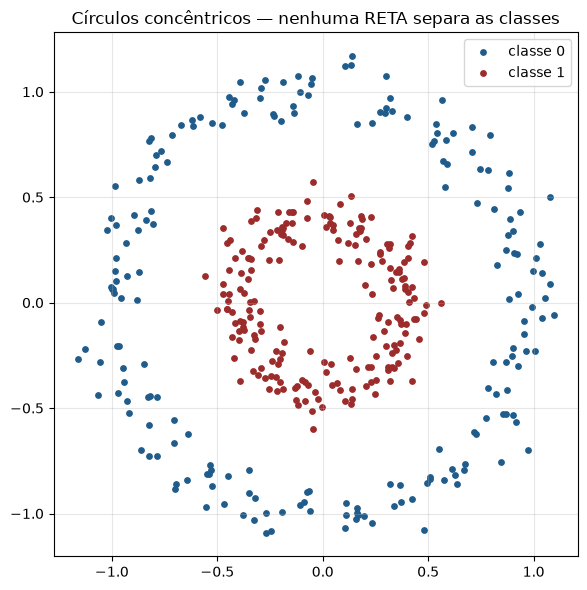

acurácia com kernel LINEAR: 0.5400  (pouco melhor que acaso)


In [3]:
X_circulos, y_circulos = make_circles(n_samples=400, noise=0.08, factor=0.4, random_state=0)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(X_circulos[y_circulos == 0, 0], X_circulos[y_circulos == 0, 1],
          s=15, color=AZUL, label="classe 0")
ax.scatter(X_circulos[y_circulos == 1, 0], X_circulos[y_circulos == 1, 1],
          s=15, color=VERMELHO, label="classe 1")
ax.set_title("Círculos concêntricos — nenhuma RETA separa as classes")
ax.set_aspect("equal"); ax.legend()
plt.tight_layout(); plt.show()

acc_linear = cross_val_score(SVC(kernel="linear"), X_circulos, y_circulos, cv=5).mean()
print(f"acurácia com kernel LINEAR: {acc_linear:.4f}  (pouco melhor que acaso)")

## 3. Kernel RBF resolve — visualizando a fronteira nos dois espaços

acurácia com kernel RBF: 1.0000


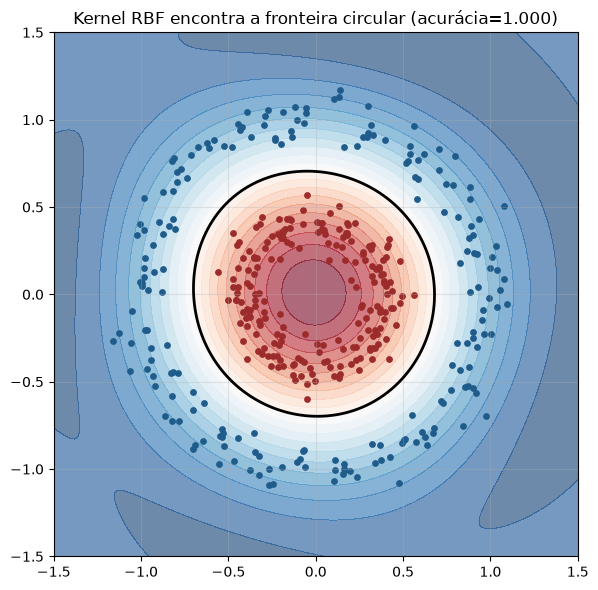

In [4]:
modelo_rbf = SVC(kernel="rbf", C=1.0, gamma=1.0).fit(X_circulos, y_circulos)
acc_rbf = cross_val_score(modelo_rbf, X_circulos, y_circulos, cv=5).mean()
print(f"acurácia com kernel RBF: {acc_rbf:.4f}")

xx, yy = np.meshgrid(np.linspace(-1.5, 1.5, 200), np.linspace(-1.5, 1.5, 200))
Z = modelo_rbf.decision_function(np.column_stack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(7, 6))
ax.contourf(xx, yy, Z, levels=20, cmap="RdBu_r", alpha=0.6)
ax.contour(xx, yy, Z, levels=[0], colors="black", linewidths=2)
ax.scatter(X_circulos[y_circulos == 0, 0], X_circulos[y_circulos == 0, 1], s=15, color=AZUL)
ax.scatter(X_circulos[y_circulos == 1, 0], X_circulos[y_circulos == 1, 1], s=15, color=VERMELHO)
ax.set_title(f"Kernel RBF encontra a fronteira circular (acurácia={acc_rbf:.3f})")
ax.set_aspect("equal")
plt.tight_layout(); plt.show()

## 4. O efeito de gamma: alcance local vs. global

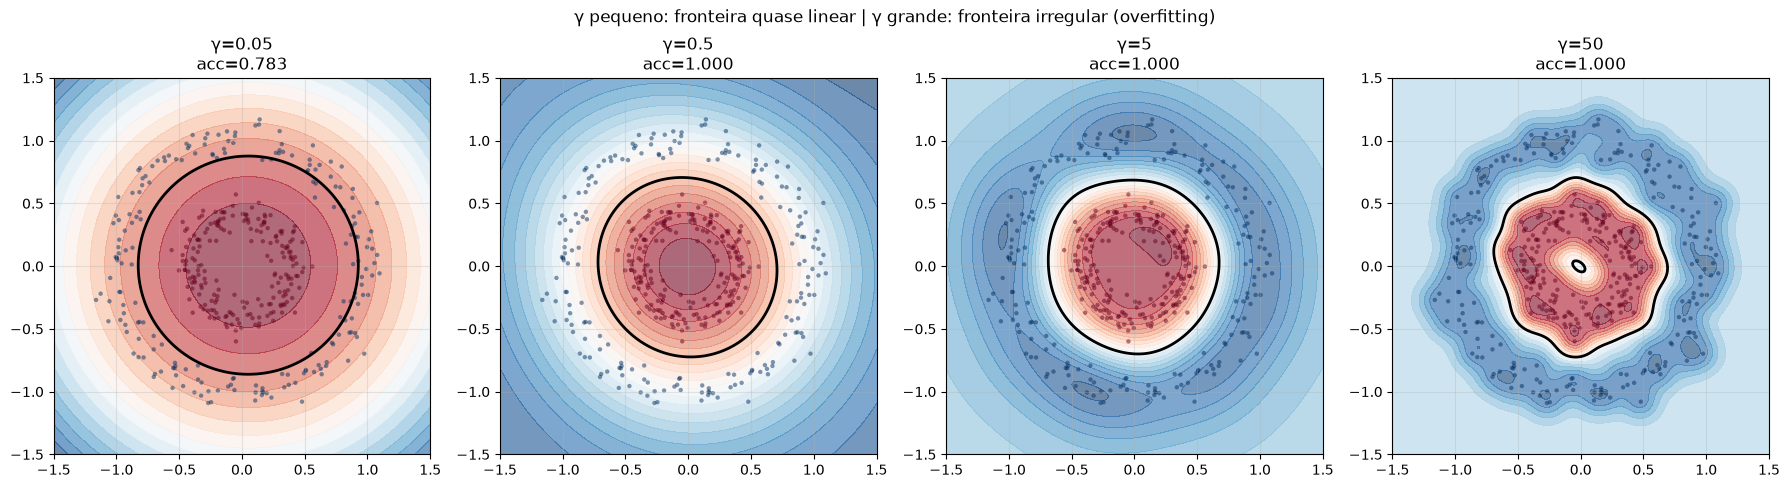

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, gamma in zip(axes, [0.05, 0.5, 5, 50]):
    modelo_g = SVC(kernel="rbf", C=1.0, gamma=gamma).fit(X_circulos, y_circulos)
    Z = modelo_g.decision_function(np.column_stack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=20, cmap="RdBu_r", alpha=0.6)
    ax.contour(xx, yy, Z, levels=[0], colors="black", linewidths=2)
    ax.scatter(X_circulos[:, 0], X_circulos[:, 1], c=y_circulos, cmap="RdBu_r",
              s=10, edgecolors="none", alpha=0.5)
    acc_g = cross_val_score(modelo_g, X_circulos, y_circulos, cv=5).mean()
    ax.set_title(f"γ={gamma}\nacc={acc_g:.3f}")
    ax.set_aspect("equal")
plt.suptitle("γ pequeno: fronteira quase linear | γ grande: fronteira irregular (overfitting)")
plt.tight_layout(); plt.show()

## 5. Ajuste conjunto de C e gamma: uma grade 2D

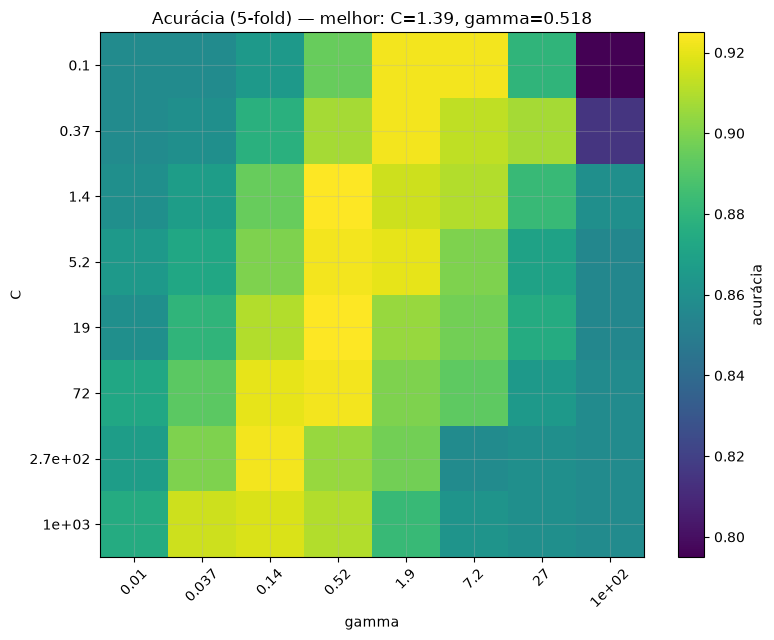

melhores hiperparâmetros: {'C': np.float64(1.3894954943731375), 'gamma': np.float64(0.517947467923121)}
melhor acurácia (5-fold): 0.9250


In [6]:
X_luas, y_luas = make_moons(n_samples=400, noise=0.25, random_state=0)
X_luas_padronizado = StandardScaler().fit_transform(X_luas)

grade_parametros = {"C": np.logspace(-1, 3, 8), "gamma": np.logspace(-2, 2, 8)}
busca = GridSearchCV(SVC(kernel="rbf"), grade_parametros, cv=5, scoring="accuracy")
busca.fit(X_luas_padronizado, y_luas)

resultados = busca.cv_results_["mean_test_score"].reshape(8, 8)

fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(resultados, cmap="viridis", aspect="auto")
ax.set_xticks(range(8)); ax.set_xticklabels([f"{g:.2g}" for g in grade_parametros["gamma"]],
                                            rotation=45)
ax.set_yticks(range(8)); ax.set_yticklabels([f"{c:.2g}" for c in grade_parametros["C"]])
ax.set_xlabel("gamma"); ax.set_ylabel("C")
ax.set_title(f"Acurácia (5-fold) — melhor: C={busca.best_params_['C']:.3g}, "
            f"gamma={busca.best_params_['gamma']:.3g}")
plt.colorbar(im, label="acurácia")
plt.tight_layout(); plt.show()

print(f"melhores hiperparâmetros: {busca.best_params_}")
print(f"melhor acurácia (5-fold): {busca.best_score_:.4f}")

**Note o formato do mapa de calor:** a região de bom desempenho geralmente
forma uma "crista" diagonal, não um retângulo alinhado aos eixos — é por
isso que ajustar $C$ e $\gamma$ **separadamente** (um de cada vez) costuma
encontrar um ótimo pior do que uma busca conjunta.

## O que levar deste notebook

- O truque do kernel calcula produtos internos num espaço expandido sem
  nunca construir esse espaço explicitamente — confirmado numericamente
  com o kernel polinomial de grau 2.
- RBF resolve problemas onde nenhuma fronteira linear funciona, ao custo
  de dois hiperparâmetros ($C$ e $\gamma$) que precisam ser ajustados
  juntos.
- $\gamma$ controla o alcance de cada ponto de treino: pequeno demais
  suaviza a fronteira até quase-linear; grande demais produz uma fronteira
  irregular e overfitada.

→ Próximo: o notebook de **exercícios** do módulo.